In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [32]:
df = pd.read_csv("data_3_1_1.csv")
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [33]:
df.shape

(100, 3)

<Axes: xlabel='x1', ylabel='class'>

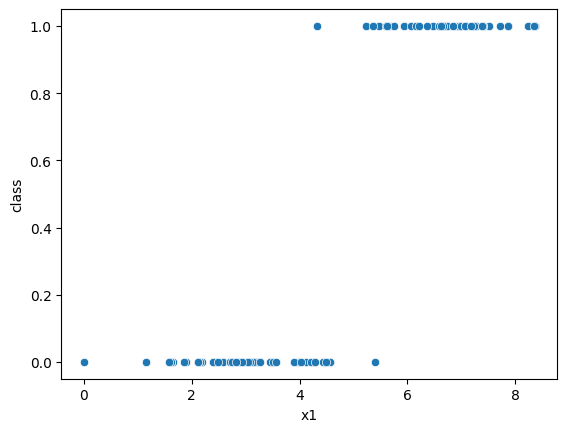

In [34]:
sns.scatterplot(x=df['x1'], y = df['class'])

<Axes: xlabel='x2', ylabel='class'>

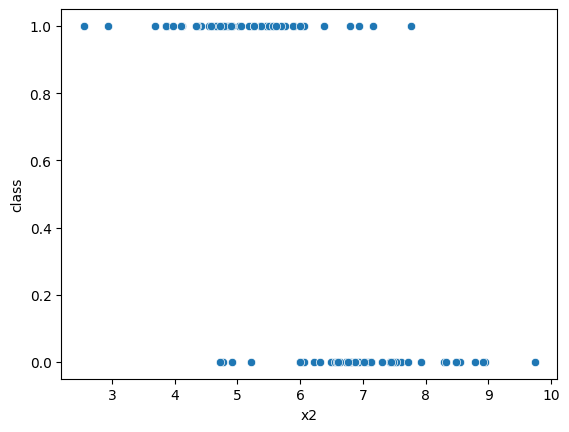

In [35]:
sns.scatterplot(x=df['x2'], y=df['class'])

<Axes: xlabel='x1', ylabel='x2'>

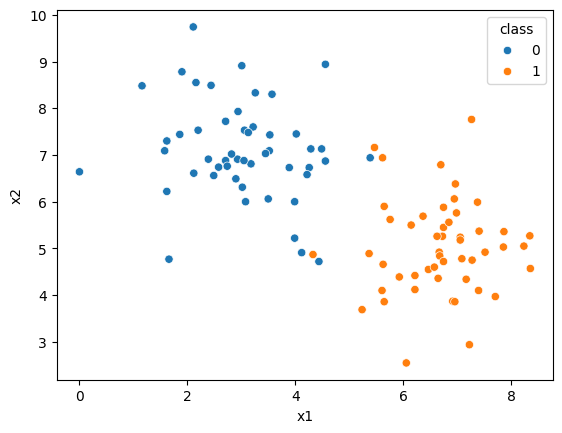

In [36]:
sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['class'])

In [37]:
# Split data
data = df.to_numpy()
X = data[:, :2]
y = data[:, 2]

X_train = X[:70]
y_train = y[:70]

X_test = X[70:]
y_test = y[70:]

print(f"train data shape: {X_train.shape}, train labels shape: {y_train.shape}")
print(f"test data shape: {X_test.shape}, test labels shape: {y_test.shape}")

train data shape: (70, 2), train labels shape: (70,)
test data shape: (30, 2), test labels shape: (30,)


In [38]:
# Scale data
mean_X_train = np.mean(X_train, axis=0)
std_X_train = np.std(X_train, axis=0)
X_train_scaled = (X_train - mean_X_train) / std_X_train
X_test_scaled = (X_test - mean_X_train) / std_X_train

print(y_train)

[1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1.
 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0.]


In [39]:
# concatenate 1 to X_train
X_train_new = np.concatenate((np.ones((X_train_scaled.shape[0],1)), X_train_scaled), axis = 1)

print(X_train_new[:5])

[[ 1.          0.98679611  0.53980269]
 [ 1.          1.09988333 -1.48693628]
 [ 1.          1.58821449 -0.45274414]
 [ 1.         -0.95110755  0.62309333]
 [ 1.          0.97137513 -0.75814316]]


In [40]:
y_train[y_train == 0] = -1
print(y_train)

[ 1.  1.  1. -1.  1.  1. -1. -1.  1. -1.  1.  1. -1. -1. -1.  1.  1. -1.
 -1. -1. -1. -1.  1.  1.  1. -1. -1. -1. -1.  1.  1.  1. -1. -1. -1. -1.
 -1.  1.  1.  1.  1. -1.  1. -1. -1. -1.  1.  1.  1.  1. -1.  1. -1. -1.
  1. -1. -1. -1. -1. -1.  1.  1.  1.  1. -1. -1.  1.  1.  1. -1.]


In [41]:
# Hypothesis function
def hypothesis(theta, X):
    return np.dot(X, theta)

In [42]:
# Hinge Loss Function
def hinge_loss(theta, lam_da, X, y):
  z = hypothesis(theta, X)
  loss = np.mean(np.maximum(0, 1 - y * z)) + lam_da*np.sum(theta[1:]**2)
  return loss

In [43]:
# Gradient function
def gradient(theta, lam_da, X, y):
  z = hypothesis(theta, X)
  grad = np.mean(-y * X.T * (1 - y * z > 0), axis=1) + 2*lam_da * theta
  return grad

In [44]:
# Training
theta = np.zeros(X_train_new.shape[1])
lam_da = 0.1
learning_rate = 0.1

for i in range(1, 1001):
  z = hypothesis(theta, X_train_new)
  loss = hinge_loss(theta, lam_da, X_train_new, y_train)
  grad = gradient(theta, lam_da, X_train_new, y_train)
  theta = theta - learning_rate * grad
  if i % 10 == 0:
    print(f"Iteration {i:04d}: Loss = {loss:.4f}")


Iteration 0010: Loss = 0.3047
Iteration 0020: Loss = 0.2671
Iteration 0030: Loss = 0.2616
Iteration 0040: Loss = 0.2602
Iteration 0050: Loss = 0.2597
Iteration 0060: Loss = 0.2594
Iteration 0070: Loss = 0.2593
Iteration 0080: Loss = 0.2593
Iteration 0090: Loss = 0.2592
Iteration 0100: Loss = 0.2592
Iteration 0110: Loss = 0.2592
Iteration 0120: Loss = 0.2592
Iteration 0130: Loss = 0.2592
Iteration 0140: Loss = 0.2592
Iteration 0150: Loss = 0.2592
Iteration 0160: Loss = 0.2592
Iteration 0170: Loss = 0.2592
Iteration 0180: Loss = 0.2592
Iteration 0190: Loss = 0.2592
Iteration 0200: Loss = 0.2592
Iteration 0210: Loss = 0.2592
Iteration 0220: Loss = 0.2592
Iteration 0230: Loss = 0.2592
Iteration 0240: Loss = 0.2592
Iteration 0250: Loss = 0.2592
Iteration 0260: Loss = 0.2592
Iteration 0270: Loss = 0.2592
Iteration 0280: Loss = 0.2592
Iteration 0290: Loss = 0.2592
Iteration 0300: Loss = 0.2592
Iteration 0310: Loss = 0.2592
Iteration 0320: Loss = 0.2592
Iteration 0330: Loss = 0.2592
Iteration 